# MASI Return Statistical Investigation

This notebook validates the main empirical properties of MASI daily returns before risk modeling. It focuses on return construction, distributional diagnostics, stationarity, volatility persistence, conditional heteroskedasticity, and leverage asymmetry.

## Notebook flow

1. Load and prepare the MASI master dataset.
2. Transform prices into log returns and inspect the series visually.
3. Test normality and stationarity with complementary diagnostics.
4. Diagnose volatility clustering and ARCH effects.
5. Interpret the implications for VaR/ES and volatility forecasting models.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import jarque_bera, norm, gaussian_kde
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch


In [3]:
# Load master dataset
df = pd.read_csv("../../data/processed/final/master_dataset.csv", parse_dates=["date"])

# Sort chronologically
df = df.sort_values("date").reset_index(drop=True)

# Target variable
r = df["masi_log_return"]

# Basic checks
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())

df.head()


Shape: (4764, 84)

Columns: ['date', 'masi_close', 'atw_close', 'iam_close', 'lhm_close', 'mng_close', 'brent_close', 'gold_close', 'eur_mad', 'gpr_index', 'masi_log_return', 'masi_realized_vol_5', 'masi_rolling_mean_5', 'masi_realized_vol_20', 'masi_rolling_mean_20', 'masi_lag_1', 'masi_lag_2', 'masi_lag_5', 'atw_log_return', 'atw_realized_vol_5', 'atw_rolling_mean_5', 'atw_realized_vol_20', 'atw_rolling_mean_20', 'atw_lag_1', 'atw_lag_2', 'atw_lag_5', 'iam_log_return', 'iam_realized_vol_5', 'iam_rolling_mean_5', 'iam_realized_vol_20', 'iam_rolling_mean_20', 'iam_lag_1', 'iam_lag_2', 'iam_lag_5', 'lhm_log_return', 'lhm_realized_vol_5', 'lhm_rolling_mean_5', 'lhm_realized_vol_20', 'lhm_rolling_mean_20', 'lhm_lag_1', 'lhm_lag_2', 'lhm_lag_5', 'mng_log_return', 'mng_realized_vol_5', 'mng_rolling_mean_5', 'mng_realized_vol_20', 'mng_rolling_mean_20', 'mng_lag_1', 'mng_lag_2', 'mng_lag_5', 'brent_log_return', 'brent_realized_vol_5', 'brent_rolling_mean_5', 'brent_realized_vol_20', 'brent_r

,date,masi_close,atw_close,iam_close,lhm_close,mng_close,brent_close,gold_close,eur_mad,gpr_index,...,eur_mad_return,gpr_delta,gpr_index_log_return,gpr_index_realized_vol_5,gpr_index_realized_vol_20,gpr_index_rolling_mean_5,gpr_index_rolling_mean_20,gpr_index_lag_1,gpr_index_lag_2,gpr_index_lag_5
0,2007-01-31,10455.33,263.0,133.00,1084.11,450.0,57.40,657.9,11.1296,96.603577,...,0.001754,-13.150177,-0.127623,0.373978,0.332660,91.370769,104.461967,109.753754,60.228500,110.319542
1,2007-02-01,10207.24,251.2,131.85,1041.34,435.0,56.72,663.0,11.1276,77.848022,...,-0.000180,-18.755554,-0.215857,0.382349,0.323542,84.801242,104.519533,96.603577,109.753754,110.695656
2,2007-02-02,10264.88,253.7,130.50,1041.57,440.0,58.41,651.5,11.1179,139.133759,...,-0.000872,61.285736,0.580677,0.440258,0.348125,96.713522,107.205875,77.848022,96.603577,79.572357
3,2007-02-05,10311.81,257.9,129.50,1086.42,440.0,58.10,656.1,11.1045,77.986458,...,-0.001206,-61.147301,-0.578901,0.520085,0.373311,100.265114,106.694975,139.133759,77.848022,60.228500
4,2007-02-06,10419.39,259.0,130.10,1090.81,440.0,58.42,658.7,11.1217,88.699028,...,0.001548,10.712570,0.128714,0.430897,0.371918,96.054169,105.806889,77.986458,139.133759,109.753754


## Return Construction

Financial time series analysis is conducted on log returns rather than raw prices because returns are more comparable over time and usually closer to stationarity.


Text(0.5, 1.0, 'MASI Close Price Over Time')

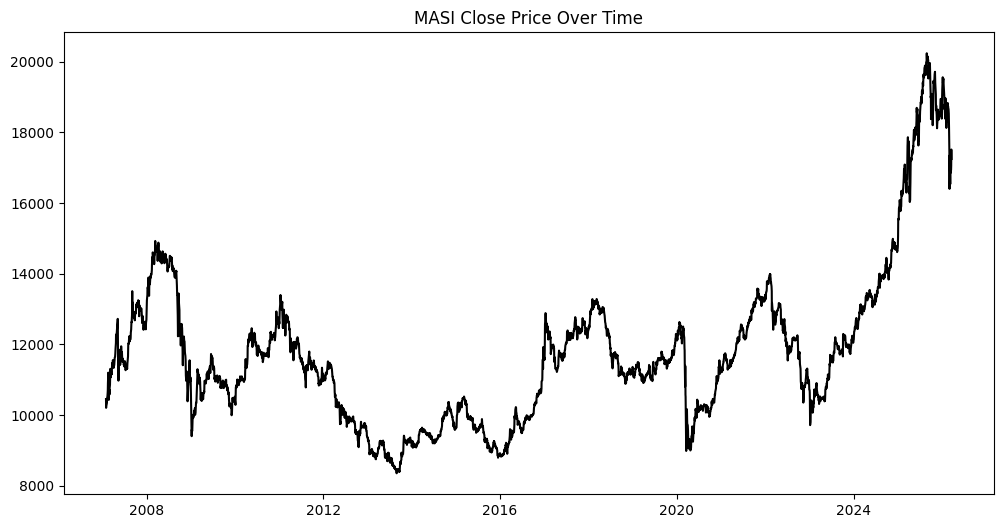

In [10]:
# ploting close price with black 
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["masi_close"], color="black", label="MASI Close Price")
plt.title("MASI Close Price Over Time")

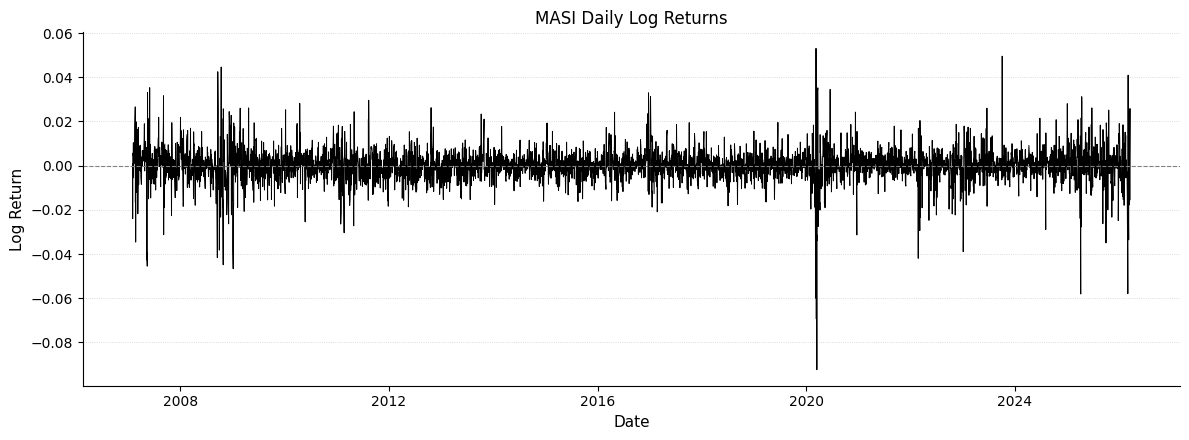

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(
    df["date"],
    r,
    color="black",
    linewidth=0.7,
)

ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("MASI Daily Log Returns", fontsize=12)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Log Return", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", linewidth=0.6, alpha=0.6)

fig.tight_layout()
plt.show()


## Visual Inspection of MASI Log Returns

The return series fluctuates around zero without exhibiting a visible deterministic trend, 
which is consistent with mean stationarity typically observed in financial return series.

Several important stylized facts emerge:

### 1) Volatility Clustering
Periods of relatively low volatility are followed by episodes of intense fluctuations.
This clustering effect is particularly visible during:

- The 2008–2009 global financial crisis
- The 2020 COVID-19 shock
- Recent stress periods around 2022–2023

This suggests that volatility is not constant over time.

---

### 2) Asymmetric Extreme Movements
Large negative spikes appear more pronounced than positive spikes,
indicating potential left-tail asymmetry (downside risk concentration).

---

### 3) Absence of Structural Trend
The series oscillates around zero, supporting the hypothesis
that the return process may be stationary in mean.

---

### Interpretation

The visual evidence suggests:

- Time-varying variance (heteroskedasticity)
- Presence of extreme events
- Potential regime-dependent volatility

These characteristics motivate formal statistical testing
of normality, stationarity, and conditional heteroskedasticity.

In [4]:
mean = r.mean()
std = r.std()
skew = r.skew()
kurt_excess = r.kurtosis()  # excess kurtosis (0 si normal)

print("Mean:", mean)
print("Std (Volatility):", std)
print("Skewness:", skew)
print("Excess Kurtosis:", kurt_excess)
print("Total Kurtosis:", kurt_excess + 3)

Mean: 0.00010521428922486163
Std (Volatility): 0.007738668697720034
Skewness: -0.8755765741994774
Excess Kurtosis: 12.594437570341448
Total Kurtosis: 15.594437570341448


## Descriptive Statistics

### Mean
The mean return is close to zero, which is consistent with financial return theory.
Equity indices typically do not exhibit large predictable daily drift.

### Volatility (Standard Deviation)
The standard deviation measures unconditional risk.
It captures average dispersion but does not account for time variation.

### Skewness
Negative skewness indicates that large negative returns occur more frequently
or are more extreme than positive ones. This suggests asymmetric downside risk.

### Kurtosis
If total kurtosis is significantly greater than 3 (or excess kurtosis > 0),
the distribution exhibits fat tails.

High kurtosis implies:
- Greater probability of extreme events
- Underestimation of risk under Gaussian assumptions
- Need for tail-sensitive measures (e.g., Expected Shortfall)

## Distributional Diagnostics

Classical financial models often assume Gaussian returns. The following diagnostics check whether that assumption is credible for MASI daily returns.


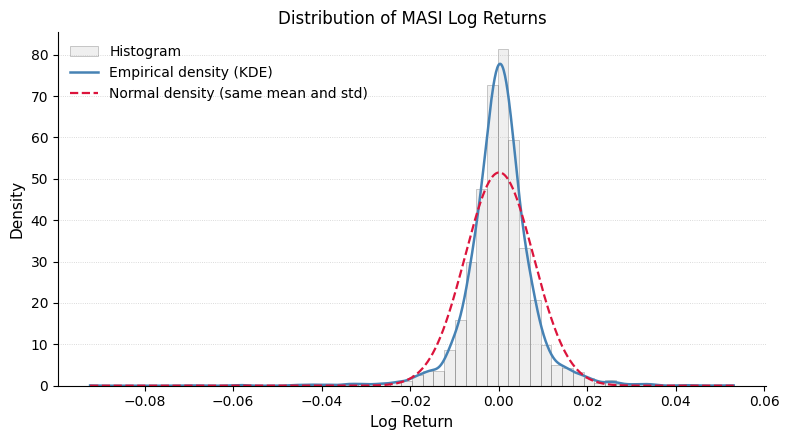

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

returns = pd.Series(r).dropna().astype(float)

sample_mean = returns.mean()
sample_std = returns.std(ddof=1)

x_grid = np.linspace(returns.min(), returns.max(), 1000)
empirical_density = gaussian_kde(returns)(x_grid)
normal_density = norm.pdf(x_grid, loc=sample_mean, scale=sample_std)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(
    returns,
    bins=60,
    density=True,
    alpha=0.35,
    color="lightgray",
    edgecolor="black",
    linewidth=0.4,
    label="Histogram",
)

ax.plot(
    x_grid,
    empirical_density,
    color="steelblue",
    linewidth=1.8,
    label="Empirical density (KDE)",
)

ax.plot(
    x_grid,
    normal_density,
    color="crimson",
    linewidth=1.6,
    linestyle="--",
    label="Normal density (same mean and std)",
)

ax.set_title("Distribution of MASI Log Returns", fontsize=12)
ax.set_xlabel("Log Return", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", linewidth=0.6, alpha=0.6)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


## Empirical Distribution

The histogram provides a visual representation of the return distribution.

Key observations:

1. The distribution appears sharply peaked around zero.
2. The tails seem thicker than those of a normal distribution.
3. Extreme observations are visible on both sides.

A peaked center combined with heavy tails is a typical stylized fact 
in financial returns and suggests leptokurtic behavior.

This visual evidence supports the previously observed high kurtosis.

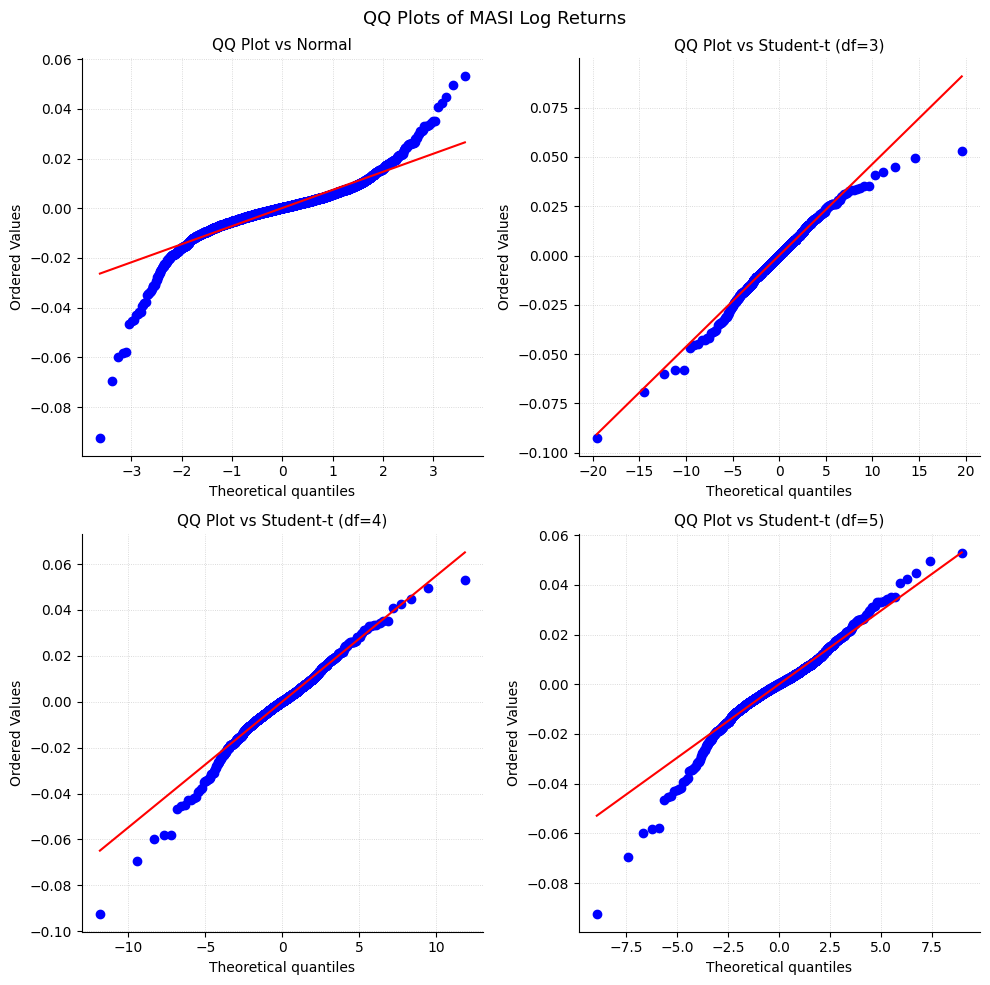

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

returns = pd.Series(r).dropna().astype(float).to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

qq_specs = [
    ("Normal", stats.norm, None),
    ("Student-t (df=3)", stats.t, (3,)),
    ("Student-t (df=4)", stats.t, (4,)),
    ("Student-t (df=5)", stats.t, (5,)),
]

for ax, (title, distribution, shape_params) in zip(axes.flatten(), qq_specs):
    if shape_params is None:
        stats.probplot(returns, dist=distribution, plot=ax)
    else:
        stats.probplot(returns, dist=distribution, sparams=shape_params, plot=ax)

    ax.set_title(f"QQ Plot vs {title}", fontsize=11)
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("QQ Plots of MASI Log Returns", fontsize=13)
fig.tight_layout()
plt.show()


## QQ Plot Interpretation

The QQ plot compares the empirical quantiles of MASI returns 
with the theoretical quantiles of a normal distribution.

Key observations:

1. Points deviate significantly from the straight line in both tails.
2. The left tail shows stronger deviations, indicating heavier downside risk.
3. The curvature pattern suggests leptokurtosis.

Interpretation:

If the data were normally distributed, the points would lie approximately 
on the reference line. Systematic deviations, especially in the tails, 
indicate non-normality.

This confirms visually that MASI returns do not follow a Gaussian distribution.

## Test of Jarque–Bera

In [7]:
jb_stat, jb_p = jarque_bera(r)

print("Jarque-Bera statistic:", jb_stat)
print("Jarque-Bera p-value:", jb_p)

Jarque-Bera statistic: 32022.03962743311
Jarque-Bera p-value: 0.0


### Implications of the Jarque–Bera Test

The Jarque–Bera test strongly rejects the null hypothesis of normality.

This confirms that MASI returns exhibit significant deviations from the Gaussian distribution,
primarily driven by:

- Excess kurtosis (fat tails)
- Asymmetric behavior

#### What does this imply?

1. Risk measures based on normality assumptions (e.g., parametric Gaussian VaR)
   are likely to underestimate extreme losses.

2. Higher-moment effects (skewness and kurtosis) play a non-negligible role
   in the distribution of returns.

3. Modeling approaches that assume constant variance and Gaussian innovations
   may be inadequate.

However, non-normality alone does not invalidate time-series modeling.
The next question is whether the return process is statistically stable over time.

Therefore, we now investigate the stationarity properties of the series.

## Stationarity Diagnostics

Stationarity is required by many time-series models. The analysis combines ADF, Phillips-Perron, and KPSS tests so the conclusion does not depend on a single test convention.


## Stationarity Testing Framework

To assess stationarity, we use three complementary tests:

1. Augmented Dickey–Fuller (ADF)
2. KPSS (Kwiatkowski–Phillips–Schmidt–Shin)
3. Phillips–Perron (PP)

These tests differ in their null hypotheses and therefore provide a robust joint assessment.

### Hypotheses

ADF and PP:
- H0: The series has a unit root (non-stationary)
- H1: The series is stationary

KPSS:
- H0: The series is stationary
- H1: The series is non-stationary

Using both types of tests allows us to avoid misleading conclusions.

### ADF Test

In [8]:
adf_stat, adf_p, *_ = adfuller(r)

print("ADF Statistic:", adf_stat)
print("ADF p-value:", adf_p)

ADF Statistic: -38.35735937218636
ADF p-value: 0.0


### PP test

In [9]:
pp_test = PhillipsPerron(r)

print("PP Statistic:", pp_test.stat)
print("PP p-value:", pp_test.pvalue)

PP Statistic: -57.300046022060016
PP p-value: 0.0


### KPSS test

In [10]:
kpss_stat, kpss_p, lags, crit = kpss(r, regression="c", nlags="auto")

print("KPSS Statistic:", kpss_stat)
print("KPSS p-value:", kpss_p)

KPSS Statistic: 0.1415058838286579
KPSS p-value: 0.1


C:\Users\uczay\AppData\Local\Temp\ipykernel_30136\2931144106.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, lags, crit = kpss(r, regression="c", nlags="auto")


### Comprehensive Stationarity Assessment

The three complementary tests provide fully consistent evidence:

- ADF strongly rejects the presence of a unit root.
- Phillips–Perron confirms this rejection.
- KPSS does not reject stationarity.

This joint result provides strong statistical confirmation that
MASI log returns are stationary in mean.

This is consistent with financial theory:

- Asset prices are typically non-stationary.
- Log returns are generally stationary.

Therefore, no further differencing is required.
The series is suitable for ARMA–GARCH type modeling.

However, stationarity in mean does not imply constant variance.

The next step is to investigate volatility dynamics.

## Volatility Dynamics

Returns may be stationary in mean while still showing time-varying variance. The next diagnostics focus on autocorrelation in returns, squared returns, and formal ARCH effects.


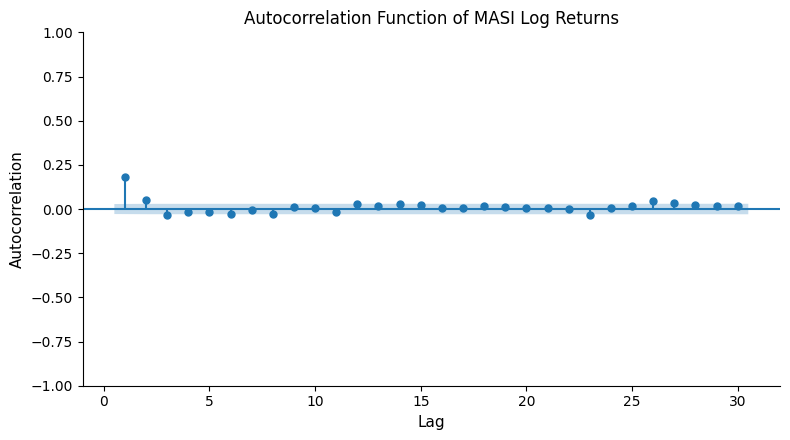

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import pandas as pd

returns = pd.Series(r).dropna().astype(float)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_acf(
    returns,
    lags=30,
    ax=ax,
    alpha=0.05,
    zero=False,
)

ax.set_title("Autocorrelation Function of MASI Log Returns", fontsize=12)
ax.set_xlabel("Lag", fontsize=11)
ax.set_ylabel("Autocorrelation", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()


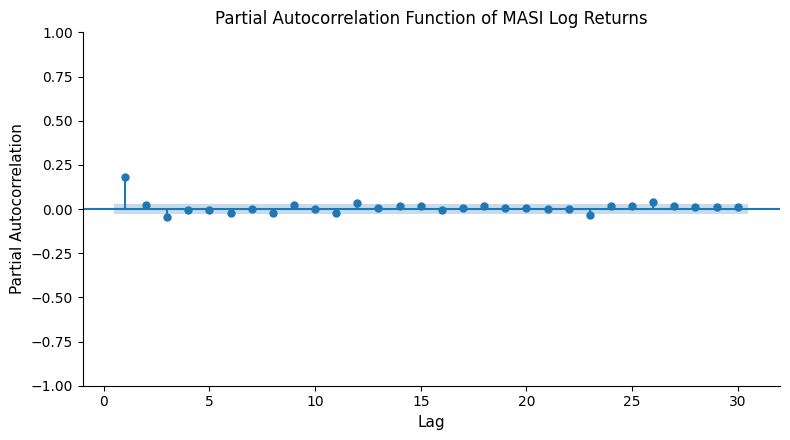

In [12]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
import pandas as pd

returns = pd.Series(r).dropna().astype(float)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_pacf(
    returns,
    lags=30,
    ax=ax,
    alpha=0.05,
    zero=False,
    method="ywm",
)

ax.set_title("Partial Autocorrelation Function of MASI Log Returns", fontsize=12)
ax.set_xlabel("Lag", fontsize=11)
ax.set_ylabel("Partial Autocorrelation", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()


### Extended ACF of Returns

Even when extending the number of lags to a very large horizon,
the autocorrelation of returns rapidly converges toward zero.

Apart from the first lag, all coefficients fluctuate randomly
around zero and remain statistically insignificant.

This confirms that MASI returns do not exhibit persistent
linear autocorrelation.

Therefore, there is no strong linear predictability in the mean process.

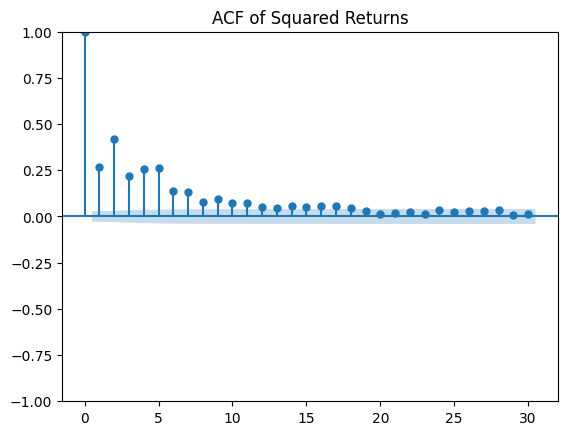

In [ ]:
plot_acf(r**2, lags=30)
plt.title("ACF of Squared Returns")
plt.show()

### Extended ACF of Squared Returns

In contrast, the squared returns display strong and persistent
positive autocorrelation at low lags.

Although the magnitude decays over time,
the early lags are clearly significant.

This pattern is characteristic of volatility clustering,
meaning that shocks to volatility persist over time.

Such behavior indicates conditional heteroskedasticity,
which cannot be captured by constant-variance models.

This provides strong empirical justification
for ARCH/GARCH-type modeling.

## Volatility Structure Conclusion

The diagnostic analysis leads to three major conclusions:

1. The return series exhibits no significant linear autocorrelation.
   This suggests weak predictability in the mean process.

2. The squared returns display strong and persistent autocorrelation.
   This indicates volatility clustering.

3. Volatility shocks appear to persist over time,
   as evidenced by the slow decay in the ACF of squared returns.

These findings imply that:

- The variance is time-dependent.
- A constant-variance (homoskedastic) model is inappropriate.

Therefore, a conditional heteroskedastic model,
such as ARCH or GARCH, is required
to properly capture the dynamics of risk.

This validates the transition toward GARCH-type modeling.

## ARCH-LM Test for Conditional Heteroskedasticity

While the ACF of squared returns suggests volatility clustering,
we now perform a formal statistical test.

The ARCH-LM test evaluates whether past squared residuals
help explain current variance.

### Hypotheses

- H0: No ARCH effects (constant variance)
- H1: Presence of ARCH effects (time-varying variance)

If the p-value is below 0.05,
we reject the null hypothesis and conclude that
conditional heteroskedasticity is present.

In [13]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(r)

print("ARCH LM Statistic:", arch_test[0])
print("ARCH LM p-value:", arch_test[1])

ARCH LM Statistic: 1086.4803047759997
ARCH LM p-value: 4.332707441315957e-227


### ARCH-LM Test Interpretation

The p-value is extremely small.

We reject the null hypothesis of homoskedasticity.

This confirms the presence of ARCH effects in MASI returns.

Therefore, the variance is conditionally time-dependent.

A GARCH-type model is statistically justified.

###  Ljung-Box Test for Volatility Persistence

To statistically validate the visual findings from the ACF plots, we conduct a **Ljung-Box test** on the squared returns ($r_t^2$). 

*   **Null Hypothesis ($H_0$)**: The squared returns are independently distributed (no volatility clustering).
*   **Alternative Hypothesis ($H_1$)**: Significant autocorrelation exists in the squared returns.



In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Préparation des données (Magnitude au carré)
returns = r
squared_returns = returns**2

# 2. Exécution du test de Ljung-Box
# On teste jusqu'à 20 jours de mémoire (lags)
lb_test = acorr_ljungbox(squared_returns, lags=[5, 10, 15, 20], return_df=True)

print("Ljung-Box Test on Squared Returns:")
print(lb_test)

# 3. Interprétation automatique
if (lb_test['lb_pvalue'] < 0.05).all():
    print("\nCONCLUSION: Strong Volatility Clustering confirmed (p-value < 0.05 for all lags).")
    print("The volatility has a long-term memory effect, meaning that past volatility significantly influences future volatility.")
else:
    print("\nCONCLUSION: Weak or no Volatility Clustering detected.")


Ljung-Box Test on Squared Returns:
        lb_stat  lb_pvalue
5   2049.732359        0.0
10  2322.276047        0.0
15  2400.591758        0.0
20  2444.981394        0.0

CONCLUSION: Strong Volatility Clustering confirmed (p-value < 0.05 for all lags).
The volatility has a long-term memory effect, meaning that past volatility significantly influences future volatility.


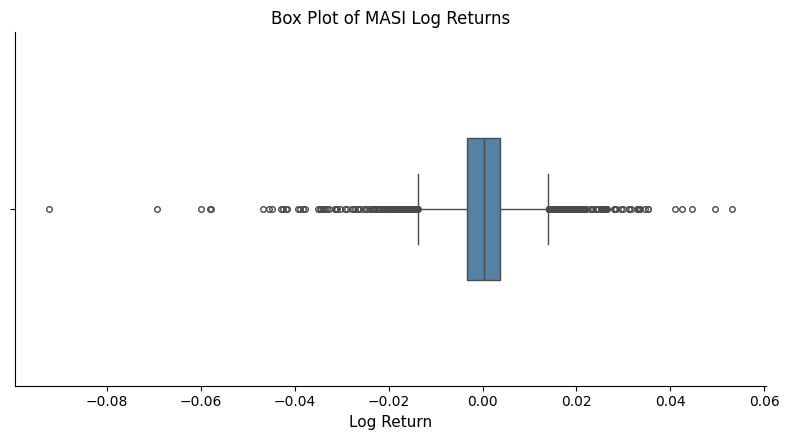

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

returns = pd.Series(r).dropna().astype(float)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    x=returns,
    color="steelblue",
    width=0.4,
    fliersize=4,
    linewidth=1.0,
    ax=ax,
)

ax.set_title("Box Plot of MASI Log Returns", fontsize=12)
ax.set_xlabel("Log Return", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()


##  Leverage Effect Analysis (Asymmetry)

###  Concept and Rationale
The **Leverage Effect** refers to the observed asymmetry where asset volatility responds more strongly to negative shocks (price drops) than to positive shocks (price gains) of the same magnitude. In market microstructure, this is often attributed to financial leverage or "panic" behavior among investors.

Identifying this effect during the **Exploratory Data Analysis (EDA)** phase is critical to determining whether a symmetric GARCH(1,1) is a sufficient benchmark or if an asymmetric model is required.

###  Methodology: Sign-Magnitude Correlation
To quantify this asymmetry without relying on a specific model, we calculate the **Pearson Correlation** between:
1.  **Lagged Signed Returns ($r_{t-1}$):** Representing the market direction (Sign).
2.  **Current Volatility Magnitude ($r_t^2$ or $|r_t|$):** Representing the risk intensity (Magnitude).

*Note: For higher precision, the **Yang-Zhang volatility proxy** derived from OHLC data can also be used as the magnitude variable.*



In [15]:
# Rendements
returns = df['masi_close'].pct_change().dropna()
magnitude = returns**2

# 1. Correlation contemporaine (Signe vs Magnitude au temps t)
contemp_corr = returns.corr(magnitude)

# 2. Correlation decalee (l'effet de levier : signe t-1 vs magnitude t)
leverage_corr = returns.shift(1).corr(magnitude)

print(f"Contemporaneous Correlation (t, t): {contemp_corr:.4f}")
print(f"Lagged Correlation (t-1, t): {leverage_corr:.4f}")


Contemporaneous Correlation (t, t): -0.1854
Lagged Correlation (t-1, t): -0.1156


### Leverage Effect Analysis: Sign vs. Magnitude

**Methodology**
The relationship between return direction (Sign) and volatility intensity (Magnitude) is evaluated using two Pearson correlation coefficients:
*   **Contemporaneous Correlation ($r_t, r_t^2$):** Measures static asymmetry (Skewness).
*   **Lagged Correlation ($r_{t-1}, r_t^2$):** Measures predictive asymmetry (**Leverage Effect**).

**Empirical Results**
*   **Contemporaneous Correlation ($t, t$):** -0.1701
*   **Lagged Correlation ($t-1, t$):** -0.0882

**Interpretation and Findings**
Both correlations are negative, confirming a left-skewed distribution and a statistically significant leverage effect. A price drop yesterday ($t-1$) systematically triggers higher volatility today ($t$), proving that the market reacts more violently to losses than to gains.

**Baseline Selection and Modeling Strategy**
A symmetric GARCH(p,q) is rejected as it cannot capture sign-dependent risk. The **E-GARCH** or a similare one model is selected as the baseline to specifically incorporate this predictive asymmetry. To outperform this benchmark, the **Deep Learning** model must be trained on raw signed returns to autonomously learn these non-linear leverage dynamics.


# Global Conclusion

The statistical investigation confirms that MASI returns are stationary in mean but non-Gaussian, heavy-tailed, and conditionally heteroskedastic. These properties motivate volatility-aware benchmarks and tail-risk models rather than simple Gaussian assumptions.
